In [6]:
# --- IMPORT LIBRARIES ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Perceptron, Ridge, Lasso
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

In [7]:
# ====================================================================
# 1. DATASET PREPARATION - DIABETES DATASET
# ====================================================================
print("="*50)
print("DIABETES DATASET FOR REGRESSION & CLASSIFICATION")
print("="*50)

# Load diabetes dataset for regression
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_reg = diabetes.target  # Continuous target for regression

# Create classification target from continuous target
# We'll create 3 classes: low, medium, high diabetes progression
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
y_clf = discretizer.fit_transform(y_reg.reshape(-1, 1)).ravel().astype(int)

print("Dataset shape:", X.shape)
print("Features:", diabetes.feature_names)
print("\nRegression target stats:")
print(f"Min: {y_reg.min()}, Max: {y_reg.max()}, Mean: {y_reg.mean():.2f}")
print("\nClassification target distribution:")
print(pd.Series(y_clf).value_counts().sort_index())
print("\nFirst 5 samples:")
display(X.head())

DIABETES DATASET FOR REGRESSION & CLASSIFICATION
Dataset shape: (442, 10)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Regression target stats:
Min: 25.0, Max: 346.0, Mean: 152.13

Classification target distribution:
0    148
1    147
2    147
Name: count, dtype: int64

First 5 samples:


e:\LClearning_Bachelor\MTH129\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [8]:
# --- TRAIN-TEST SPLIT ---
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


2. ORDINARY LEAST SQUARES (OLS) REGRESSION

Top 5 OLS Coefficients:


,Feature,Coefficient
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902


Intercept: 151.3456

Test MSE: 2900.19
R-squared: 0.4526


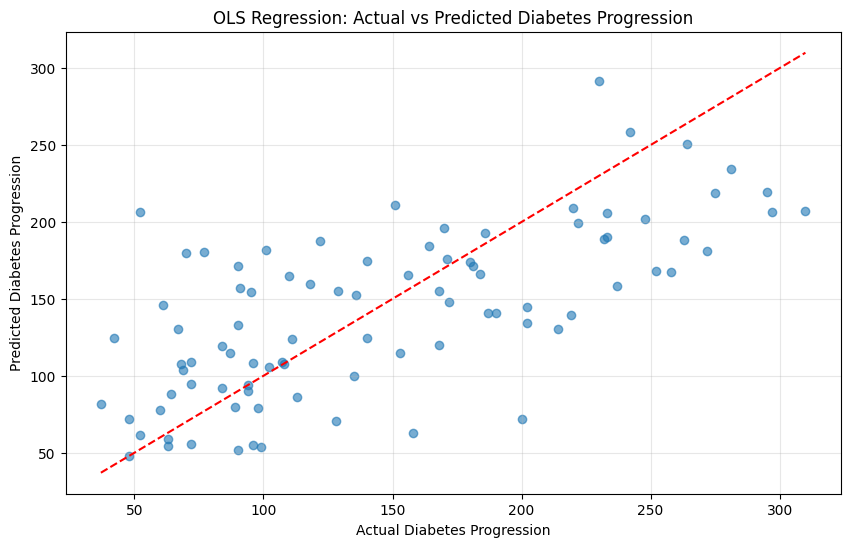

In [9]:
# ====================================================================
# 2. ORDINARY LEAST SQUARES (OLS) REGRESSION
# ====================================================================
print("\n" + "="*50)
print("2. ORDINARY LEAST SQUARES (OLS) REGRESSION")
print("="*50)

ols = LinearRegression()
ols.fit(X_train, y_train_reg)
ols_pred = ols.predict(X_test)
ols_mse = mean_squared_error(y_test_reg, ols_pred)

print("\nTop 5 OLS Coefficients:")
coef_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': ols.coef_
}).sort_values('Coefficient', ascending=False).head(5)
display(coef_df)

print(f"Intercept: {ols.intercept_:.4f}")
print(f"\nTest MSE: {ols_mse:.2f}")
print(f"R-squared: {ols.score(X_test, y_test_reg):.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, ols_pred, alpha=0.6)
plt.plot([min(y_test_reg), max(y_test_reg)], [min(y_test_reg), max(y_test_reg)], 'r--')
plt.title("OLS Regression: Actual vs Predicted Diabetes Progression")
plt.xlabel("Actual Diabetes Progression")
plt.ylabel("Predicted Diabetes Progression")
plt.grid(alpha=0.3)
plt.show()



3. WEIGHTED LEAST SQUARES (WLS) REGRESSION

Top 5 WLS Coefficients:


,Feature,Coefficient
8,s5,744.019999
2,bmi,546.865869
5,s2,538.780570
3,bp,352.130019
7,s4,282.400540


Intercept: 151.3124

Test MSE: 2909.77
R-squared: 0.4508


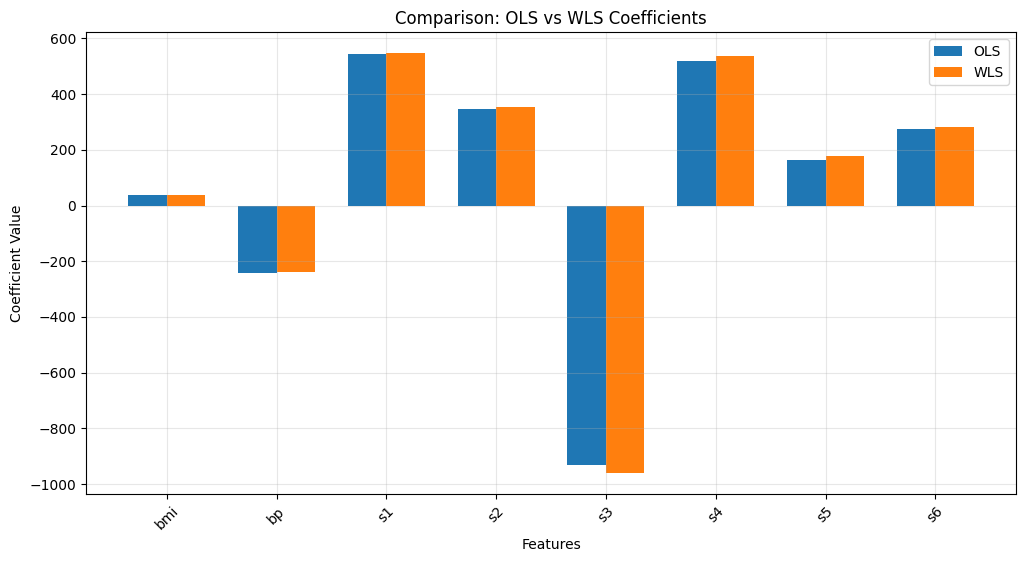

In [10]:
# ====================================================================
# 3. WEIGHTED LEAST SQUARES (WLS) REGRESSION
# ====================================================================
print("\n" + "="*50)
print("3. WEIGHTED LEAST SQUARES (WLS) REGRESSION")
print("="*50)

# Create heteroscedastic weights based on BMI (higher BMI gets higher weight)
weights = X_train['bmi'] + 1  # Add 1 to avoid zero weights

wls = LinearRegression()
wls.fit(X_train, y_train_reg, sample_weight=weights)
wls_pred = wls.predict(X_test)
wls_mse = mean_squared_error(y_test_reg, wls_pred)

print("\nTop 5 WLS Coefficients:")
wls_coef_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': wls.coef_
}).sort_values('Coefficient', ascending=False).head(5)
display(wls_coef_df)

print(f"Intercept: {wls.intercept_:.4f}")
print(f"\nTest MSE: {wls_mse:.2f}")
print(f"R-squared: {wls.score(X_test, y_test_reg):.4f}")

# Compare OLS vs WLS coefficients
plt.figure(figsize=(12, 6))
features = ['bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
index = np.arange(len(features))
bar_width = 0.35

plt.bar(index, ols.coef_[:len(features)], bar_width, label='OLS')
plt.bar(index + bar_width, wls.coef_[:len(features)], bar_width, label='WLS')

plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Comparison: OLS vs WLS Coefficients')
plt.xticks(index + bar_width/2, features, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

e:\LClearning_Bachelor\MTH129\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



4. LOGISTIC REGRESSION (Diabetes Risk Classification)

Top 5 Logistic Regression Coefficients:


,Feature,Coefficient
5,s2,1.587457
6,s3,1.075445
1,sex,0.342815
9,s6,0.030775
7,s4,0.027368


Intercept: -0.3235

Accuracy: 0.5955
Class distribution in test set: [34 28 27]


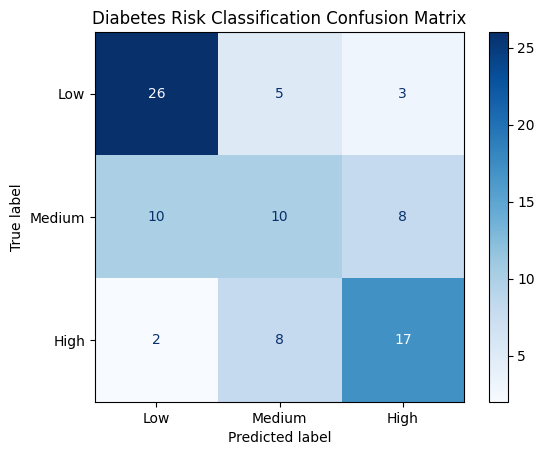

In [11]:
# ====================================================================
# 4. LOGISTIC REGRESSION (Classification)
# ====================================================================
print("\n" + "="*50)
print("4. LOGISTIC REGRESSION (Diabetes Risk Classification)")
print("="*50)

log_reg = LogisticRegression(penalty=None, max_iter=1000)  # No regularization
log_reg.fit(X_train_scaled, y_train_clf)
log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_prob = log_reg.predict_proba(X_test_scaled)
accuracy = accuracy_score(y_test_clf, log_reg_pred)

print("\nTop 5 Logistic Regression Coefficients:")
log_coef_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False).head(5)
display(log_coef_df)

print(f"Intercept: {log_reg.intercept_[0]:.4f}")
print(f"\nAccuracy: {accuracy:.4f}")
print("Class distribution in test set:", np.bincount(y_test_clf))

# Confusion matrix
cm = confusion_matrix(y_test_clf, log_reg_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title('Diabetes Risk Classification Confusion Matrix')
plt.show()

In [12]:
# ====================================================================
# 5. PERCEPTRON (Linear Classifier)
# ====================================================================
print("\n" + "="*50)
print("5. PERCEPTRON (Diabetes Risk Classification)")
print("="*50)

perceptron = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
perceptron.fit(X_train_scaled, y_train_clf)
perceptron_pred = perceptron.predict(X_test_scaled)
accuracy = accuracy_score(y_test_clf, perceptron_pred)

print("\nTop 5 Perceptron Coefficients:")
perc_coef_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': perceptron.coef_[0]
}).sort_values('Coefficient', ascending=False).head(5)
display(perc_coef_df)

print(f"Intercept: {perceptron.intercept_[0]:.4f}")
print(f"\nAccuracy: {accuracy:.4f}")


5. PERCEPTRON (Diabetes Risk Classification)

Top 5 Perceptron Coefficients:


,Feature,Coefficient
5,s2,0.760586
6,s3,0.635117
1,sex,0.188436
9,s6,0.175190
3,bp,0.040896


Intercept: -0.2000

Accuracy: 0.5506


In [13]:
# ====================================================================
# 6. PENALIZED OLS (Ridge & Lasso Regression)
# ====================================================================
print("\n" + "="*50)
print("6. PENALIZED OLS (Ridge & Lasso Regression)")
print("="*50)

# Initialize models
ridge = Ridge(alpha=0.5)  # Regularization strength
lasso = Lasso(alpha=0.02, max_iter=10000)

# Train models
ridge.fit(X_train_scaled, y_train_reg)
lasso.fit(X_train_scaled, y_train_reg)

# Make predictions and evaluate
ridge_pred = ridge.predict(X_test_scaled)
lasso_pred = lasso.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test_reg, ridge_pred)
lasso_mse = mean_squared_error(y_test_reg, lasso_pred)

print("\nRidge Coefficients Summary:")
print(f"Non-zero coefficients: {np.sum(ridge.coef_ != 0)}/10")
ridge_coef_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': ridge.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(5)
display(ridge_coef_df)
print(f"Test MSE: {ridge_mse:.2f}")

print("\nLasso Coefficients Summary:")
print(f"Non-zero coefficients: {np.sum(lasso.coef_ != 0)}/10")
lasso_coef_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(5)
display(lasso_coef_df)
print(f"Test MSE: {lasso_mse:.2f}")



6. PENALIZED OLS (Ridge & Lasso Regression)

Ridge Coefficients Summary:
Non-zero coefficients: 10/10


,Feature,Coefficient
4,s1,-38.911299
8,s5,33.020742
2,bmi,25.682350
5,s2,20.339446
3,bp,16.777532


Test MSE: 2895.34

Lasso Coefficients Summary:
Non-zero coefficients: 10/10


,Feature,Coefficient
4,s1,-41.427655
8,s5,34.054339
2,bmi,25.650675
5,s2,22.365531
3,bp,16.791928


Test MSE: 2896.60


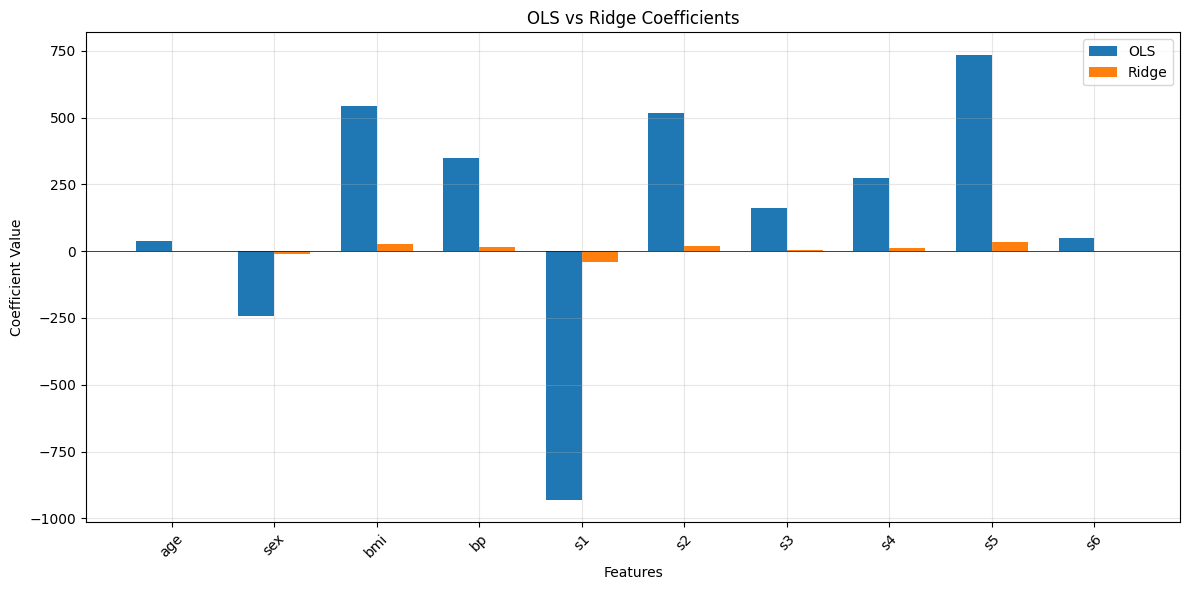

In [14]:
# Plot coefficients comparison
plt.figure(figsize=(12, 6))
features = diabetes.feature_names
x = np.arange(len(features))
width = 0.35

plt.bar(x - width/2, ols.coef_, width, label='OLS')
plt.bar(x + width/2, ridge.coef_, width, label='Ridge')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('OLS vs Ridge Coefficients')
plt.xticks(x, features, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



7. PENALIZED LOGISTIC REGRESSION (Diabetes Risk Classification)

L1 Regularized (Lasso) Logistic Coefficients Summary:
Non-zero coefficients: 5/10


e:\LClearning_Bachelor\MTH129\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\LClearning_Bachelor\MTH129\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
e:\LClearning_Bachelor\MTH129\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf in

,Feature,Coefficient
8,s5,-0.494933
6,s3,0.304769
2,bmi,-0.222257
1,sex,0.091238
3,bp,-0.081764


Accuracy: 0.5955

L2 Regularized (Ridge) Logistic Coefficients Summary:
Non-zero coefficients: 10/10


,Feature,Coefficient
8,s5,-0.523376
2,bmi,-0.383221
3,bp,-0.330808
6,s3,0.308765
1,sex,0.249170


Accuracy: 0.5618


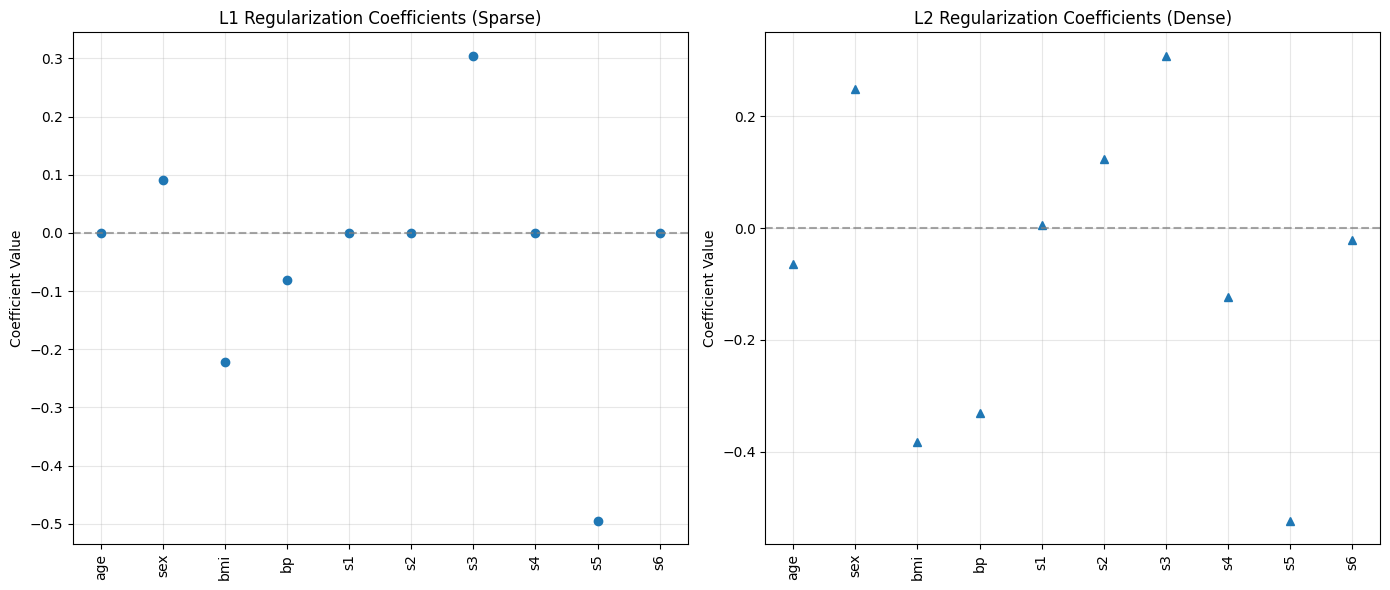

In [15]:
# ====================================================================
# 7. PENALIZED LOGISTIC REGRESSION (L1 & L2 Regularization)
# ====================================================================
print("\n" + "="*50)
print("7. PENALIZED LOGISTIC REGRESSION (Diabetes Risk Classification)")
print("="*50)

# Initialize regularized logistic models
log_reg_l1 = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, C=0.1)
log_reg_l2 = LogisticRegression(penalty='l2', max_iter=1000, C=0.1)

# Train models
log_reg_l1.fit(X_train_scaled, y_train_clf)
log_reg_l2.fit(X_train_scaled, y_train_clf)

# Make predictions and evaluate
log_reg_l1_pred = log_reg_l1.predict(X_test_scaled)
log_reg_l2_pred = log_reg_l2.predict(X_test_scaled)
accuracy_l1 = accuracy_score(y_test_clf, log_reg_l1_pred)
accuracy_l2 = accuracy_score(y_test_clf, log_reg_l2_pred)

print("\nL1 Regularized (Lasso) Logistic Coefficients Summary:")
print(f"Non-zero coefficients: {np.sum(log_reg_l1.coef_[0] != 0)}/10")
l1_coef_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': log_reg_l1.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(5)
display(l1_coef_df)
print(f"Accuracy: {accuracy_l1:.4f}")

print("\nL2 Regularized (Ridge) Logistic Coefficients Summary:")
print(f"Non-zero coefficients: {np.sum(log_reg_l2.coef_[0] != 0)}/10")
l2_coef_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': log_reg_l2.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(5)
display(l2_coef_df)
print(f"Accuracy: {accuracy_l2:.4f}")

# Plot regularization paths
plt.figure(figsize=(14, 6))

# L1 regularization
plt.subplot(1, 2, 1)
plt.plot(log_reg_l1.coef_[0], 'o')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
plt.xticks(range(len(diabetes.feature_names)), diabetes.feature_names, rotation=90)
plt.title("L1 Regularization Coefficients (Sparse)")
plt.ylabel("Coefficient Value")
plt.grid(alpha=0.3)

# L2 regularization
plt.subplot(1, 2, 2)
plt.plot(log_reg_l2.coef_[0], '^')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
plt.xticks(range(len(diabetes.feature_names)), diabetes.feature_names, rotation=90)
plt.title("L2 Regularization Coefficients (Dense)")
plt.ylabel("Coefficient Value")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()